Mediana IDHM: 0.699
Mediana SAEB: 246.77


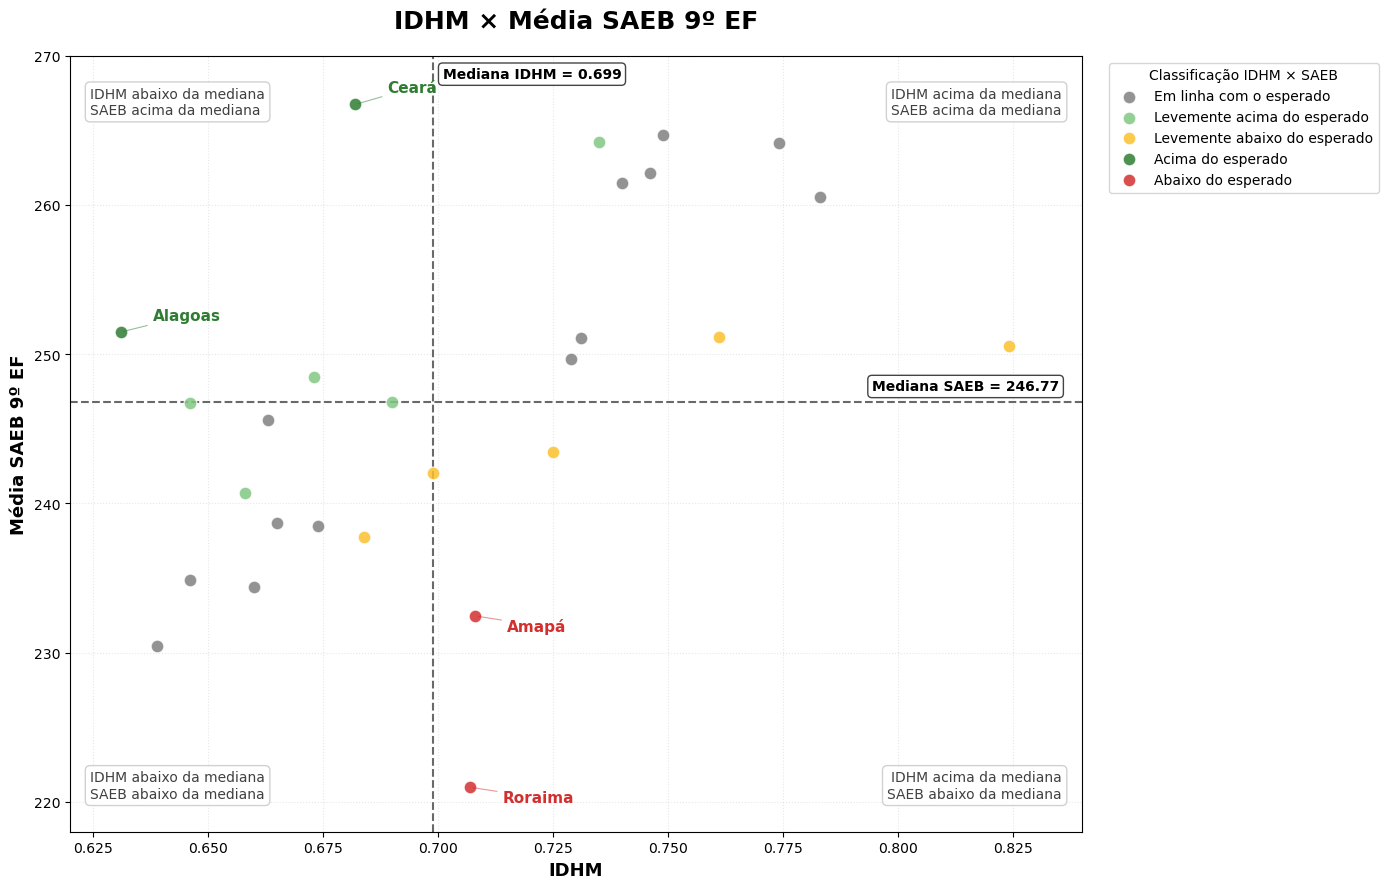

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 1. Dados
# ============================================================

dados = [
    ["Paraná", 264.71, 0.749, "Em linha com o esperado"],
    ["Santa Catarina", 264.17, 0.774, "Em linha com o esperado"],
    ["Rio Grande do Sul", 262.12, 0.746, "Em linha com o esperado"],
    ["Espírito Santo", 261.47, 0.740, "Em linha com o esperado"],
    ["São Paulo", 260.55, 0.783, "Em linha com o esperado"],
    ["Minas Gerais", 251.06, 0.731, "Em linha com o esperado"],
    ["Mato Grosso do Sul", 249.65, 0.729, "Em linha com o esperado"],
    ["Acre", 245.60, 0.663, "Em linha com o esperado"],
    ["Sergipe", 238.72, 0.665, "Em linha com o esperado"],
    ["Amazonas", 238.52, 0.674, "Em linha com o esperado"],
    ["Pará", 234.84, 0.646, "Em linha com o esperado"],
    ["Bahia", 234.40, 0.660, "Em linha com o esperado"],
    ["Maranhão", 230.43, 0.639, "Em linha com o esperado"],

    ["Goiás", 264.20, 0.735, "Levemente acima do esperado"],
    ["Rio de Janeiro", 251.18, 0.761, "Levemente abaixo do esperado"],
    ["Distrito Federal", 250.52, 0.824, "Levemente abaixo do esperado"],
    ["Pernambuco", 248.46, 0.673, "Levemente acima do esperado"],
    ["Rondônia", 246.77, 0.690, "Levemente acima do esperado"],
    ["Piauí", 246.72, 0.646, "Levemente acima do esperado"],
    ["Mato Grosso", 243.46, 0.725, "Levemente abaixo do esperado"],
    ["Tocantins", 242.01, 0.699, "Levemente abaixo do esperado"],
    ["Paraíba", 240.70, 0.658, "Levemente acima do esperado"],
    ["Rio Grande do Norte", 237.76, 0.684, "Levemente abaixo do esperado"],

    ["Ceará", 266.74, 0.682, "Acima do esperado"],
    ["Alagoas", 251.48, 0.631, "Acima do esperado"],
    ["Amapá", 232.47, 0.708, "Abaixo do esperado"],
    ["Roraima", 220.98, 0.707, "Abaixo do esperado"],
]

df = pd.DataFrame(
    dados,
    columns=[
        "Estado",
        "Media_SAEB_9EF",
        "IDHM",
        "Classificacao"
    ]
)

# ============================================================
# 2. Medianas
# ============================================================

mediana_idhm = df["IDHM"].median()
mediana_saeb = df["Media_SAEB_9EF"].median()

print(f"Mediana IDHM: {mediana_idhm:.3f}")
print(f"Mediana SAEB: {mediana_saeb:.2f}")

# ============================================================
# 3. Cores
# ============================================================

cores = {
    "Acima do esperado": "#2E7D32",              # Verde
    "Levemente acima do esperado": "#81C784",    # Verde claro
    "Em linha com o esperado": "#808080",        # Cinza
    "Levemente abaixo do esperado": "#FBC02D",   # Amarelo
    "Abaixo do esperado": "#D32F2F"              # Vermelho
}

# ============================================================
# 4. Criar gráfico
# ============================================================

fig, ax = plt.subplots(figsize=(14, 9))

# ============================================================
# 5. Plotar os pontos
# ============================================================

ordem = [
    "Em linha com o esperado",
    "Levemente acima do esperado",
    "Levemente abaixo do esperado",
    "Acima do esperado",
    "Abaixo do esperado"
]

for classificacao in ordem:

    dados_categoria = df[
        df["Classificacao"] == classificacao
    ]

    ax.scatter(
        dados_categoria["IDHM"],
        dados_categoria["Media_SAEB_9EF"],
        s=85,
        color=cores[classificacao],
        label=classificacao,
        alpha=0.85,
        edgecolor="white",
        linewidth=0.9,
        zorder=3
    )

# ============================================================
# 6. Linhas das medianas
# ============================================================

ax.axvline(
    mediana_idhm,
    color="#444444",
    linestyle="--",
    linewidth=1.5,
    alpha=0.8,
    zorder=2
)

ax.axhline(
    mediana_saeb,
    color="#444444",
    linestyle="--",
    linewidth=1.5,
    alpha=0.8,
    zorder=2
)

# ============================================================
# 7. Rótulos das medianas
# ============================================================

ax.text(
    mediana_idhm + 0.002,
    268.5,
    f"Mediana IDHM = {mediana_idhm:.3f}",
    fontsize=10,
    fontweight="bold",
    bbox=dict(
        boxstyle="round,pad=0.3",
        facecolor="white",
        edgecolor="#444444"
    ),
    zorder=5
)

ax.text(
    0.835,
    mediana_saeb + 0.8,
    f"Mediana SAEB = {mediana_saeb:.2f}",
    fontsize=10,
    fontweight="bold",
    ha="right",
    bbox=dict(
        boxstyle="round,pad=0.3",
        facecolor="white",
        edgecolor="#444444"
    ),
    zorder=5
)

# ============================================================
# 8. Rótulos dos estados
#    Apenas "Acima" e "Abaixo do esperado"
# ============================================================

posicoes = {
    "Ceará": (0.007, 0.8),
    "Alagoas": (0.007, 0.8),
    "Amapá": (0.007, -1.0),
    "Roraima": (0.007, -1.0),
}

for _, linha in df[
    df["Classificacao"].isin(
        ["Acima do esperado", "Abaixo do esperado"]
    )
].iterrows():

    estado = linha["Estado"]

    deslocamento_x, deslocamento_y = posicoes.get(
        estado,
        (0.005, 0.5)
    )

    ax.annotate(
        estado,
        xy=(
            linha["IDHM"],
            linha["Media_SAEB_9EF"]
        ),
        xytext=(
            linha["IDHM"] + deslocamento_x,
            linha["Media_SAEB_9EF"] + deslocamento_y
        ),
        fontsize=11,
        fontweight="bold",
        color=cores[linha["Classificacao"]],
        arrowprops=dict(
            arrowstyle="-",
            color=cores[linha["Classificacao"]],
            alpha=0.5,
            linewidth=0.8
        ),
        zorder=4
    )

# ============================================================
# 9. Identificação dos quadrantes
#
#    Usamos coordenadas relativas ao gráfico (0 a 1),
#    evitando que os textos fiquem sobre as linhas.
# ============================================================

# Quadrante superior esquerdo
ax.text(
    0.02,
    0.96,
    "IDHM abaixo da mediana\nSAEB acima da mediana",
    transform=ax.transAxes,
    fontsize=10,
    alpha=0.75,
    va="top",
    ha="left",
    bbox=dict(
        boxstyle="round,pad=0.35",
        facecolor="white",
        edgecolor="#cccccc",
        alpha=0.9
    ),
    zorder=4
)

# Quadrante superior direito
ax.text(
    0.98,
    0.96,
    "IDHM acima da mediana\nSAEB acima da mediana",
    transform=ax.transAxes,
    fontsize=10,
    alpha=0.75,
    va="top",
    ha="right",
    bbox=dict(
        boxstyle="round,pad=0.35",
        facecolor="white",
        edgecolor="#cccccc",
        alpha=0.9
    ),
    zorder=4
)

# Quadrante inferior esquerdo
ax.text(
    0.02,
    0.04,
    "IDHM abaixo da mediana\nSAEB abaixo da mediana",
    transform=ax.transAxes,
    fontsize=10,
    alpha=0.75,
    va="bottom",
    ha="left",
    bbox=dict(
        boxstyle="round,pad=0.35",
        facecolor="white",
        edgecolor="#cccccc",
        alpha=0.9
    ),
    zorder=4
)

# Quadrante inferior direito
ax.text(
    0.98,
    0.04,
    "IDHM acima da mediana\nSAEB abaixo da mediana",
    transform=ax.transAxes,
    fontsize=10,
    alpha=0.75,
    va="bottom",
    ha="right",
    bbox=dict(
        boxstyle="round,pad=0.35",
        facecolor="white",
        edgecolor="#cccccc",
        alpha=0.9
    ),
    zorder=4
)

# ============================================================
# 10. Título e eixos
# ============================================================

ax.set_title(
    "IDHM × Média SAEB 9º EF",
    fontsize=18,
    fontweight="bold",
    pad=20
)

ax.set_xlabel(
    "IDHM",
    fontsize=13,
    fontweight="bold"
)

ax.set_ylabel(
    "Média SAEB 9º EF",
    fontsize=13,
    fontweight="bold"
)

# ============================================================
# 11. Limites e grade
# ============================================================

ax.set_xlim(0.62, 0.84)
ax.set_ylim(218, 270)

ax.grid(
    True,
    linestyle=":",
    alpha=0.3
)

# ============================================================
# 12. Legenda
# ============================================================

ax.legend(
    title="Classificação IDHM × SAEB",
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    frameon=True
)

# ============================================================
# 13. Ajustes finais
# ============================================================

plt.tight_layout()

plt.savefig(
    "idhm_vs_saeb_9ef.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
